In [13]:
import os
from PIL import Image
import hashlib
from collections import Counter
import numpy as np
import matplotlib.pyplot as plt
import shutil
import random


In [14]:
dataset1 = "dataset_n"
dataset2 = "datasetv2_TrainUclean_n"

paths = [
    os.path.join(dataset1, "train"),
    os.path.join(dataset1, "test"),
    os.path.join(dataset1, "unclean"),
    os.path.join(dataset2, "train"),
    os.path.join(dataset2, "unclean")
]

for path in paths:

    for folder in os.listdir(path):

        folder_path = os.path.join(path, folder)

        if os.path.isdir(folder_path):

            print(f"Folder {os.path.basename(path)}:", folder)

            for image_name in os.listdir(folder_path):

                image_path = os.path.join(folder_path, image_name)

                try:
                    image = Image.open(image_path)
                    image.verify()

                except:
                    print("corrupted image:", image_path)

    print('===================================')

Folder train: ambulance
Folder train: autobus
Folder train: kamyun
Folder train: kamyunet
Folder train: minibus
Folder train: savari
Folder train: taxi
Folder train: vanet
Folder test: ambulance
Folder test: autobus
Folder test: kamyun
Folder test: kamyunet
Folder test: minibus
Folder test: savari
Folder test: taxi
Folder test: vanet
Folder unclean: ambulance
Folder unclean: autobus
Folder unclean: kamyun
Folder unclean: kamyunet
Folder unclean: minibus
Folder unclean: neysan
Folder unclean: savari
Folder unclean: taxi
Folder unclean: vanet
Folder train: ambulance
Folder train: autobus
Folder train: kamyun
Folder train: kamyunet
Folder train: minibus
Folder train: savari
Folder train: taxi
Folder train: vanet
Folder unclean: ambulance
Folder unclean: autobus
Folder unclean: kamyun
Folder unclean: kamyunet
Folder unclean: minibus
Folder unclean: neysan
Folder unclean: savari
Folder unclean: taxi
Folder unclean: vanet


In [15]:
test_path = os.path.join(dataset1, "test")

train1 = os.path.join(dataset1, "train")
unclean1 = os.path.join(dataset1, "unclean")

train2 = os.path.join(dataset2, "train")
unclean2 = os.path.join(dataset2, "unclean")

def get_md5(file_path):

    md5 = hashlib.md5()

    with open(file_path, "rb") as f:
        for chunk in iter(lambda: f.read(4096), b""):
            md5.update(chunk)

    return md5.hexdigest()

def get_files(folder_path):

    files = []

    for folder in os.listdir(folder_path):

        folder_path2 = os.path.join(folder_path, folder)

        if os.path.isdir(folder_path2):

            for image_name in os.listdir(folder_path2):

                image_path = os.path.join(folder_path2, image_name)

                try:
                    file_hash = get_md5(image_path)

                    files.append(
                        (file_hash, image_path, folder)
                    )

                except:
                    pass

    return files

test_files = get_files(test_path)

test_hashes = {
    file_hash: label
    for file_hash, path, label in test_files
}

train1_files = get_files(train1)

train1_hashes = {
    file_hash: label
    for file_hash, path, label in train1_files
}

train2_files = get_files(train2)

train2_hashes = {
    file_hash: label
    for file_hash, path, label in train2_files
}

files_to_delete = []
label_conflicts = []

for file_hash, path, label in get_files(unclean1):

    if file_hash in test_hashes:

        files_to_delete.append(
            (path, "duplicate with TEST")
        )

        if label != test_hashes[file_hash]:

            label_conflicts.append(
                (
                    path,
                    label,
                    "TEST",
                    test_hashes[file_hash]
                )
            )

    elif file_hash in train1_hashes:

        files_to_delete.append(
            (path, "duplicate with dataset1 TRAIN")
        )

        if label != train1_hashes[file_hash]:

            label_conflicts.append(
                (
                    path,
                    label,
                    "dataset1 TRAIN",
                    train1_hashes[file_hash]
                )
            )

    elif file_hash in train2_hashes:

        files_to_delete.append(
            (path, "duplicate with dataset2 TRAIN")
        )

        if label != train2_hashes[file_hash]:

            label_conflicts.append(
                (
                    path,
                    label,
                    "dataset2 TRAIN",
                    train2_hashes[file_hash]
                )
            )

for file_hash, path, label in get_files(unclean2):

    if file_hash in test_hashes:

        files_to_delete.append(
            (path, "duplicate with TEST")
        )

        if label != test_hashes[file_hash]:

            label_conflicts.append(
                (
                    path,
                    label,
                    "TEST",
                    test_hashes[file_hash]
                )
            )

    elif file_hash in train1_hashes:

        files_to_delete.append(
            (path, "duplicate with dataset1 TRAIN")
        )

        if label != train1_hashes[file_hash]:

            label_conflicts.append(
                (
                    path,
                    label,
                    "dataset1 TRAIN",
                    train1_hashes[file_hash]
                )
            )

    elif file_hash in train2_hashes:

        files_to_delete.append(
            (path, "duplicate with dataset2 TRAIN")
        )

        if label != train2_hashes[file_hash]:

            label_conflicts.append(
                (
                    path,
                    label,
                    "dataset2 TRAIN",
                    train2_hashes[file_hash]
                )
            )

print("Files to delete:", len(files_to_delete))

for path, reason in files_to_delete:

    print("\nDELETE:")
    print(path)

    print("Reason:")
    print(reason)

print("\n===================================")
print("LABEL CONFLICTS:", len(label_conflicts))

for path, unclean_label, dataset_name, existing_label in label_conflicts:

    print("\nCONFLICT:")
    print(path)

    print("Unclean label:")
    print(unclean_label)

    print("Existing dataset:")
    print(dataset_name)

    print("Existing label:")
    print(existing_label)

Files to delete: 0

LABEL CONFLICTS: 0


In [16]:
for path, reason in files_to_delete:

    os.remove(path)

    print("Deleted:", path)
    print("Reason:", reason)

In [17]:
folders = {
    "dataset/train": os.path.join(dataset1, "train"),
    "dataset/test": os.path.join(dataset1, "test"),
    "dataset/unclean": os.path.join(dataset1, "unclean"),
    "datasetv2/train": os.path.join(dataset2, "train"),
    "datasetv2/unclean": os.path.join(dataset2, "unclean")
}

def get_hashes(folder_path):

    hashes = {}

    for folder in os.listdir(folder_path):

        folder_path2 = os.path.join(folder_path, folder)

        if os.path.isdir(folder_path2):

            for image_name in os.listdir(folder_path2):

                image_path = os.path.join(folder_path2, image_name)

                try:
                    file_hash = get_md5(image_path)
                    hashes[file_hash] = image_path

                except:
                    pass

    return hashes

all_hashes = {}

for name, path in folders.items():

    print("Checking:", name)

    all_hashes[name] = get_hashes(path)

names = list(all_hashes.keys())

for i in range(len(names)):

    for j in range(i + 1, len(names)):

        name1 = names[i]
        name2 = names[j]

        hashes1 = all_hashes[name1]
        hashes2 = all_hashes[name2]

        duplicates = set(hashes1.keys()) & set(hashes2.keys())

        print("\n==============================================")
        print(name1, "<->", name2)
        print("Duplicate count:", len(duplicates))

        for file_hash in duplicates:

            print("  ", hashes1[file_hash])
            print("  ", hashes2[file_hash])

Checking: dataset/train
Checking: dataset/test
Checking: dataset/unclean
Checking: datasetv2/train
Checking: datasetv2/unclean

dataset/train <-> dataset/test
Duplicate count: 0

dataset/train <-> dataset/unclean
Duplicate count: 0

dataset/train <-> datasetv2/train
Duplicate count: 0

dataset/train <-> datasetv2/unclean
Duplicate count: 0

dataset/test <-> dataset/unclean
Duplicate count: 0

dataset/test <-> datasetv2/train
Duplicate count: 0

dataset/test <-> datasetv2/unclean
Duplicate count: 0

dataset/unclean <-> datasetv2/train
Duplicate count: 0

dataset/unclean <-> datasetv2/unclean
Duplicate count: 0

datasetv2/train <-> datasetv2/unclean
Duplicate count: 0


In [18]:
paths = [
    ("dataset/train", os.path.join("dataset_n", "train")),
    ("dataset/test", os.path.join("dataset_n", "test")),
    ("dataset/unclean", os.path.join("dataset_n", "unclean")),
    ("datasetv2/train", os.path.join("datasetv2_TrainUclean_n", "train")),
    ("datasetv2/unclean", os.path.join("datasetv2_TrainUclean_n", "unclean"))
]

for name, path in paths:

    sizes = Counter()

    for folder in os.listdir(path):

        folder_path = os.path.join(path, folder)

        if os.path.isdir(folder_path):

            for image_name in os.listdir(folder_path):

                image_path = os.path.join(folder_path, image_name)

                try:
                    image = Image.open(image_path)
                    sizes[image.size] += 1

                except:
                    pass

    print(f"\n{name}")
    print("-" * 30)

    for size, count in sizes.most_common():
        print(f"{size}: {count}")


dataset/train
------------------------------
(198, 264): 14
(189, 252): 13
(186, 252): 12
(180, 240): 9
(177, 240): 9
(189, 240): 7
(198, 252): 7
(195, 264): 7
(156, 204): 6
(162, 216): 6
(207, 276): 6
(180, 228): 4
(150, 192): 4
(210, 276): 4
(186, 240): 3
(349, 448): 3
(340, 448): 3
(347, 448): 3
(168, 228): 3
(162, 204): 2
(186, 235): 2
(165, 216): 2
(207, 274): 2
(171, 216): 2
(201, 264): 2
(331, 448): 2
(341, 448): 2
(326, 448): 2
(210, 261): 2
(198, 251): 2
(177, 228): 2
(328, 365): 1
(286, 328): 1
(269, 397): 1
(270, 355): 1
(305, 353): 1
(248, 313): 1
(279, 366): 1
(284, 339): 1
(207, 273): 1
(198, 247): 1
(270, 361): 1
(370, 553): 1
(129, 180): 1
(390, 870): 1
(207, 264): 1
(321, 812): 1
(361, 324): 1
(337, 367): 1
(415, 398): 1
(241, 280): 1
(545, 590): 1
(318, 393): 1
(361, 450): 1
(341, 450): 1
(318, 450): 1
(395, 448): 1
(370, 448): 1
(344, 444): 1
(403, 448): 1
(344, 448): 1
(388, 442): 1
(406, 448): 1
(339, 448): 1
(365, 448): 1
(333, 448): 1
(311, 379): 1
(411, 448): 1


Dataset1 Train
ambulance: 1 small images


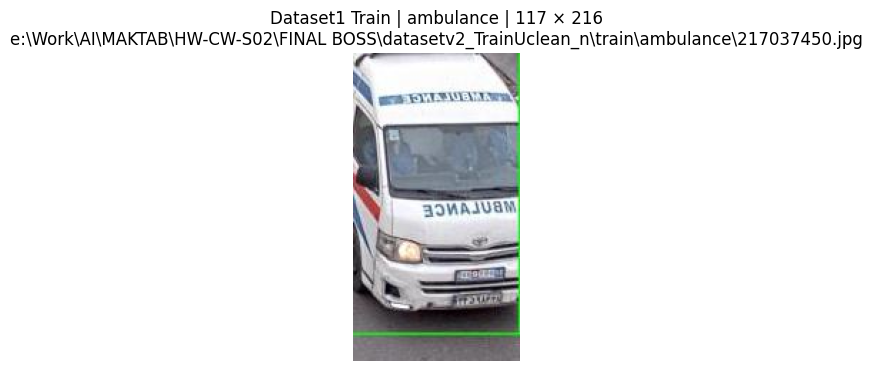

autobus: 0 small images
kamyun: 0 small images
kamyunet: 0 small images
minibus: 0 small images
savari: 0 small images
taxi: 0 small images
vanet: 0 small images

Dataset1 Test
ambulance: 0 small images
autobus: 0 small images
kamyun: 0 small images
kamyunet: 0 small images
minibus: 0 small images
savari: 0 small images
taxi: 0 small images
vanet: 0 small images

Dataset1 Unclean
ambulance: 0 small images
autobus: 0 small images
kamyun: 0 small images
kamyunet: 0 small images
minibus: 0 small images
neysan: 0 small images
savari: 0 small images
taxi: 0 small images
vanet: 0 small images

Dataset2 Train
ambulance: 0 small images
autobus: 0 small images
kamyun: 0 small images
kamyunet: 0 small images
minibus: 0 small images
savari: 0 small images
taxi: 0 small images
vanet: 0 small images

Dataset2 Unclean
ambulance: 0 small images
autobus: 0 small images
kamyun: 0 small images
kamyunet: 0 small images
minibus: 0 small images
neysan: 0 small images
savari: 0 small images
taxi: 0 small im

In [24]:

paths = [
    ("Dataset1 Train", train_path),
    ("Dataset1 Test", test_path),
    ("Dataset1 Unclean", unclean_path),
    ("Dataset2 Train", train2),
    ("Dataset2 Unclean", unclean2)
]

shown_images = set()

for name, path in paths:

    print(f"\n{name}")

    for folder in os.listdir(path):

        folder_path = os.path.join(path, folder)

        if os.path.isdir(folder_path):

            small_images = []

            for image_name in os.listdir(folder_path):

                image_path = os.path.abspath(
                    os.path.join(folder_path, image_name)
                )

                if image_path in shown_images:
                    continue

                try:
                    image = Image.open(image_path)

                    width, height = image.size

                    if width < 120 or height < 120:

                        small_images.append(
                            (image_path, width, height)
                        )

                        shown_images.add(image_path)

                    if len(small_images) == 2:
                        break

                except:
                    pass

            print(f"{folder}: {len(small_images)} small images")

            for image_path, width, height in small_images:

                image = Image.open(image_path)

                plt.figure(figsize=(4, 4))

                plt.imshow(image)

                plt.title(
                    f"{name} | {folder} | {width} × {height}\n{image_path}"
                )

                plt.axis("off")

                plt.show()




Train
------------------------------
ambulance: 169
autobus: 195
kamyun: 200
kamyunet: 188
minibus: 180
savari: 200
taxi: 200
vanet: 200


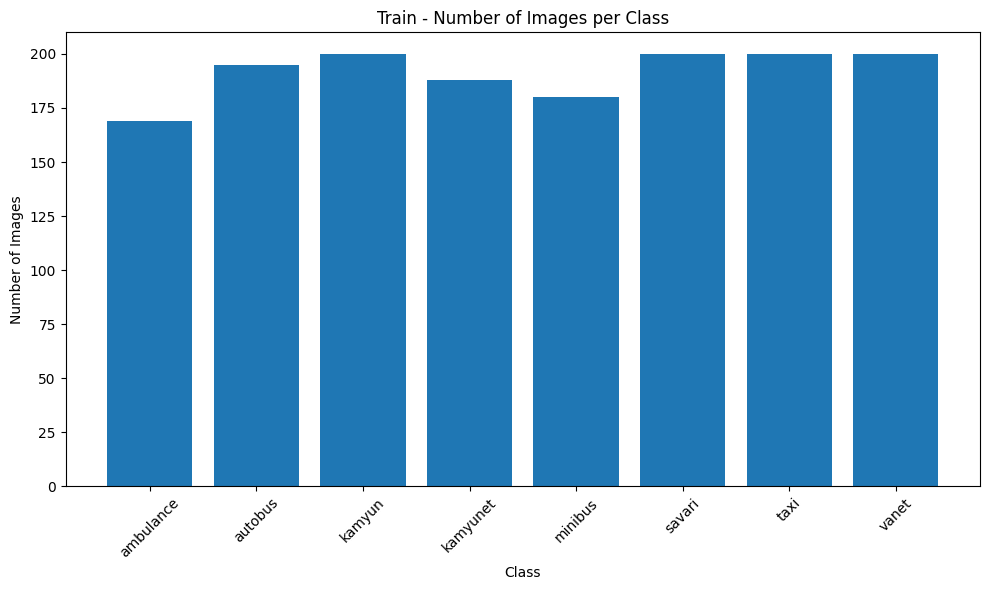


Test
------------------------------
ambulance: 50
autobus: 50
kamyun: 50
kamyunet: 50
minibus: 50
savari: 50
taxi: 50
vanet: 50


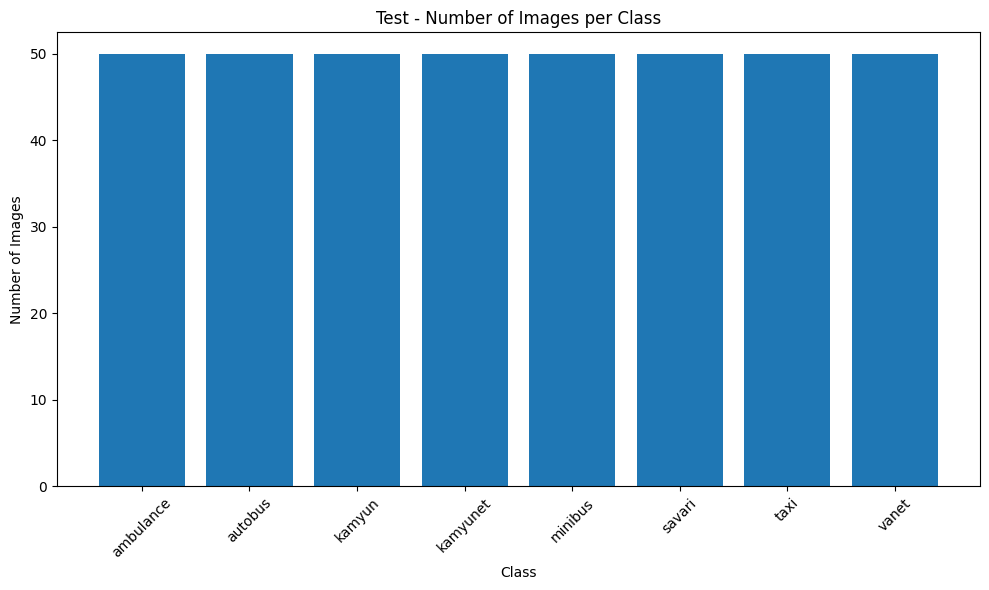


Unclean
------------------------------
ambulance: 107
autobus: 176
kamyun: 196
kamyunet: 171
minibus: 135
neysan: 200
savari: 200
taxi: 193
vanet: 200


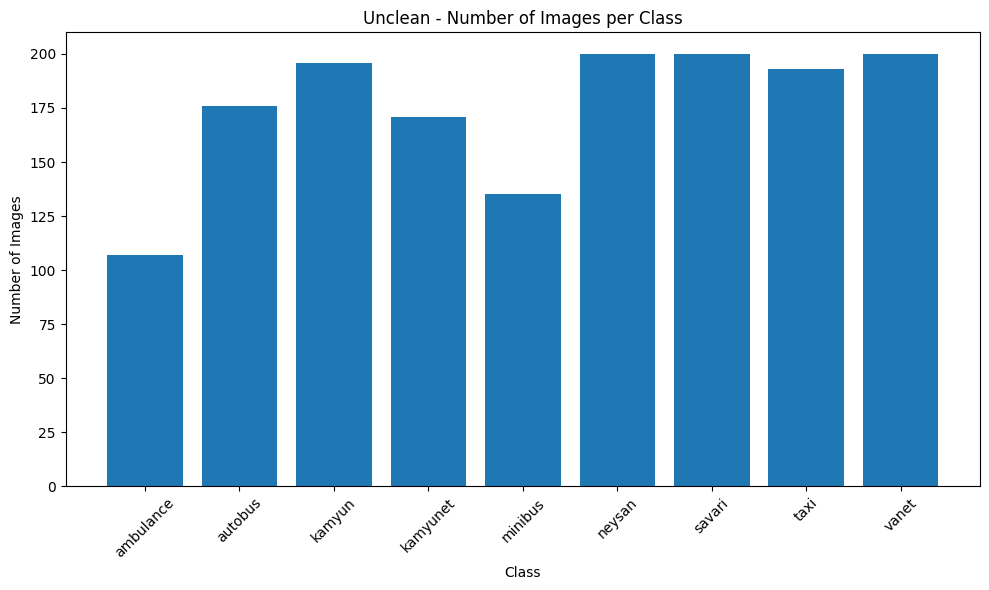


Train_v2
------------------------------
ambulance: 169
autobus: 195
kamyun: 200
kamyunet: 188
minibus: 180
savari: 200
taxi: 200
vanet: 200


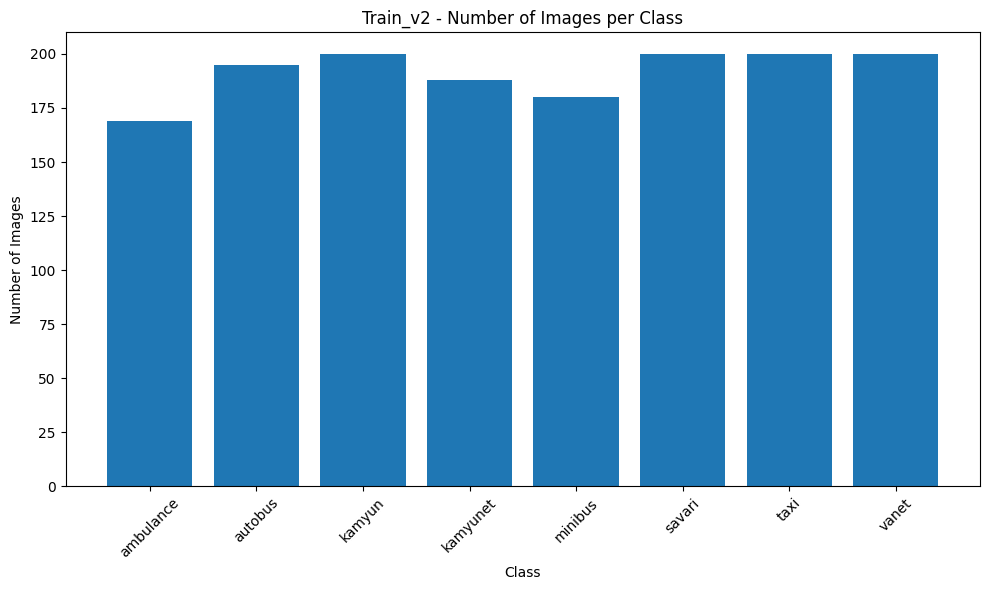


Unclean_v2
------------------------------
ambulance: 107
autobus: 176
kamyun: 196
kamyunet: 171
minibus: 135
neysan: 200
savari: 200
taxi: 193
vanet: 200


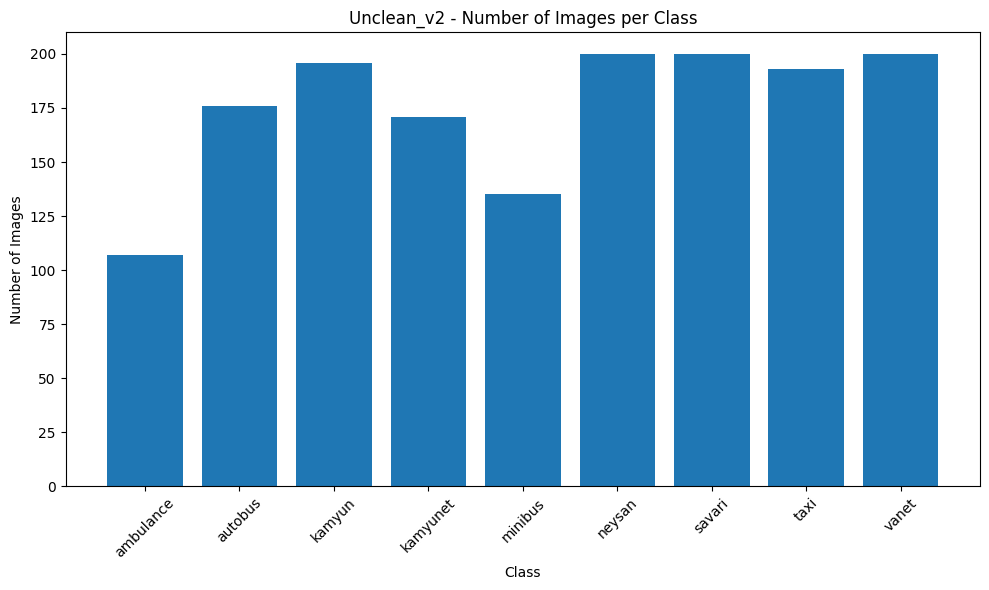

In [23]:
datasets = [
    ("Train", train_path),
    ("Test", test_path),
    ("Unclean", unclean_path),
    ("Train_v2", train2),
    ("Unclean_v2", unclean2)
]

all_counts = {}

for name, path in datasets:

    counts = {}

    for folder in sorted(os.listdir(path)):

        folder_path = os.path.join(path, folder)

        if os.path.isdir(folder_path):

            count = 0

            for image_name in os.listdir(folder_path):

                image_path = os.path.join(folder_path, image_name)

                if os.path.isfile(image_path):
                    count += 1

            counts[folder] = count

    all_counts[name] = counts

    print(f"\n{name}")
    print("-" * 30)

    for folder, count in counts.items():
        print(f"{folder}: {count}")

    plt.figure(figsize=(10, 6))

    plt.bar(
        counts.keys(),
        counts.values()
    )

    plt.xlabel("Class")
    plt.ylabel("Number of Images")
    plt.title(f"{name} - Number of Images per Class")

    plt.xticks(rotation=45)

    plt.tight_layout()

    plt.savefig(
        f"{name.lower()}_class_distribution.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

In [6]:
dataset_path = "dataset"

train_path = os.path.join(dataset_path, "train")

unclean_path = os.path.join(dataset_path, "unclean")

merged_path = os.path.join(dataset_path, "merged_dataset")

merged_train_path = os.path.join(merged_path, "train")

random.seed(42)

os.makedirs(merged_train_path, exist_ok=True)

In [ ]:
train_paths = [
    os.path.join("dataset_n", "train"),
    os.path.join("datasetv2_TrainUclean_n", "train")
]

for train_path in train_paths:

    for folder in os.listdir(train_path):

        source_folder = os.path.join(train_path, folder)
        destination_folder = os.path.join(merged_train_path, folder)

        if os.path.isdir(source_folder):

            os.makedirs(destination_folder, exist_ok=True)

            for image_name in os.listdir(source_folder):

                source = os.path.join(source_folder, image_name)
                destination = os.path.join(destination_folder, image_name)

                if os.path.isfile(source):
                    shutil.copy2(source, destination)

In [10]:
classes = [
    "ambulance",
    "autobus",
    "kamyun",
    "kamyunet",
    "minibus",
    "savari",
    "taxi",
    "vanet"
]

unclean_paths = [
    os.path.join("dataset_n", "unclean"),
    os.path.join("datasetv2_TrainUclean_n", "unclean")
]

for unclean_path in unclean_paths:

    for folder in classes:

        source_folder = os.path.join(unclean_path, folder)
        destination_folder = os.path.join(merged_train_path, folder)

        os.makedirs(destination_folder, exist_ok=True)

        images = os.listdir(source_folder)

        for image_name in images:

            source = os.path.join(source_folder, image_name)
            destination = os.path.join(
                destination_folder,
                "unclean_" + image_name
            )

            if os.path.isfile(source):
                shutil.copy2(source, destination)

In [12]:
for folder in sorted(os.listdir(merged_train_path)):

    folder_path = os.path.join(merged_train_path, folder)

    if os.path.isdir(folder_path):

        count = len([
            f for f in os.listdir(folder_path)
            if os.path.isfile(os.path.join(folder_path, f))
        ])

        print(f"{folder}: {count}")

ambulance: 362
autobus: 470
kamyun: 496
kamyunet: 455
minibus: 411
savari: 500
taxi: 493
vanet: 500
